In [129]:
import numpy as np

矩阵的转置

In [130]:
A = np.array([
    [1, 2],
    [3, 4],
    [5, 6]])

print(A)
# calculate transpose
C = A.T
print(C)

[[1 2]
 [3 4]
 [5 6]]
[[1 3 5]
 [2 4 6]]


矩阵的逆

In [131]:
A = np.array([
    [1, 2],
    [3, 4]])
print('矩阵：\n', A)

B = np.linalg.inv(A)
print('逆：\n', B)

print(B.astype(str))

print(A.dot(B))

矩阵：
 [[1 2]
 [3 4]]
逆：
 [[-2.   1. ]
 [ 1.5 -0.5]]
[['-1.9999999999999996' '0.9999999999999998']
 ['1.4999999999999998' '-0.4999999999999999']]
[[1.0000000e+00 0.0000000e+00]
 [8.8817842e-16 1.0000000e+00]]


矩阵的迹

In [132]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]])
print(A)

B = np.trace(A)
print(B)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
15


矩阵的秩

In [133]:
v1 = np.array([1,2,3,4]).reshape(2,2)
print(v1)
r1 = np.linalg.matrix_rank(v1)
print(r1)

v2 = np.array([[1,2], [2,4]])
print(v2)
r2 = np.linalg.matrix_rank(v2)
print(r2)

# zero rank
v3 = np.array([[0,0,0],[0,0,0]])
print(v3)
r3 = np.linalg.matrix_rank(v3)
print(r3)

[[1 2]
 [3 4]]
2
[[1 2]
 [2 4]]
1
[[0 0 0]
 [0 0 0]]
0


In [134]:
v1 = np.array([1,2,3,4,5,6]).reshape(3,2)
print(v1)
r1 = np.linalg.matrix_rank(v1)

print(r1)

[[1 2]
 [3 4]
 [5 6]]
2


In [135]:
v1 = np.array([1,2,0,3,4,0,5,6,8]).reshape(3,3)
print(v1)
r1 = np.linalg.matrix_rank(v1)
print(r1)

[[1 2 0]
 [3 4 0]
 [5 6 8]]
3


# 行列式


In [136]:
# A = np.arange(21, 37).reshape(4,4)
A = np.array([[2,3,4], [5,6,7],[1,2,1]])
print(A)
deta = np.linalg.det(A)
print(deta)
np.allclose(np.array([5,6]), np.array([5.00000000001, 6]))

[[2 3 4]
 [5 6 7]
 [1 2 1]]
5.999999999999997


True

坐标变换

A1（闭合后的原始坐标）:
 [[1. 2. 2. 1. 1.]
 [1. 1. 2. 2. 1.]]
B（变换后的坐标）:
 [[3 5 6 4]
 [3 4 6 5]]
B1（闭合后的变换坐标）:
 [[3. 5. 6. 4. 3.]
 [3. 4. 6. 5. 3.]]


/Users/bytedance/workspace/learning/aistudio/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bytedance/workspace/learning/aistudio/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bytedance/workspace/learning/aistudio/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bytedance/workspace/learning/aistudio/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bytedance

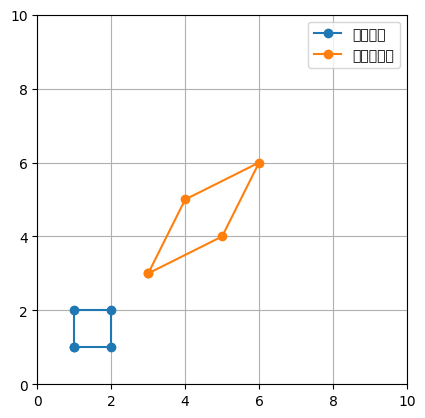

In [137]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 1. 定义原始数据与变换矩阵 ----------------------
# T: 线性变换矩阵（对称正定矩阵，会对图形进行拉伸变形）
T = [[2, 1], [1, 2]]

# A: 原始正方形的 4 个顶点坐标（逆时针顺序：(1,1)→(2,1)→(2,2)→(1,2)）
A = [[1, 1], [2, 1], [2, 2], [1, 2]]

# ---------------------- 2. 处理原始图形坐标（闭合处理） ----------------------
# A1: 构造 2×5 的矩阵，用于存储闭合后的原始图形坐标
# 前 4 列是正方形顶点（转置为列向量），第 5 列重复第 1 列，让图形闭合
A1 = np.zeros((2, 5))
A1[:, :-1] = np.array(A).T  # 将 A 转置为列向量（shape: 2×4），放入前 4 列
A1[:, -1] = np.array(A).T[:, 0]  # 补充第一个顶点，让图形闭合
print("A1（闭合后的原始坐标）:\n", A1)

# ---------------------- 3. 执行线性变换（矩阵乘法） ----------------------
# B: 用变换矩阵 T 对原始顶点做线性变换
# 计算方式：T (2×2) @ A.T (2×4) = B (2×4)，得到变换后的 4 个新顶点
B = np.dot(T, np.array(A).T)
print("B（变换后的坐标）:\n", B)

# ---------------------- 4. 处理变换后图形坐标（闭合处理） ----------------------
# B1: 同理，构造闭合后的变换图形坐标
B1 = np.zeros((2, 5))
B1[:, :-1] = B  # 变换后的顶点放入前 4 列
B1[:, -1] = B[:, 0]  # 补充第一个顶点，让图形闭合
print("B1（闭合后的变换坐标）:\n", B1)

# ---------------------- 5. 可视化对比 ----------------------
# 创建画布和子图
f, ax = plt.subplots(1)

# 绘制原始正方形（蓝色，带圆形标记）
ax.plot(A1[0], A1[1], marker='o', label='原始图形')

# 绘制变换后的图形（橙色，带圆形标记）
ax.plot(B1[0], B1[1], marker='o', label='变换后图形')

# 设置坐标轴范围（0到10，避免图形被截断）
ax.set_xlim(xmin=0, xmax=10)
ax.set_ylim(ymin=0, ymax=10)

# 设置坐标轴等比例（关键！防止图形因窗口比例变形）
ax.set_aspect('equal')

# 显示网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()

In [138]:
T = np.array([[2,1],[1,2]])
print(T.dot([1,1]))
print(T.dot([1,-1]))

np.linalg.det(T)

[3 3]
[ 1 -1]


np.float64(2.9999999999999996)

In [139]:
import numpy as np

# 创建一个矩阵
A = np.array([[1.5, -0.5], [-0.5, 1.5]])

# 计算特征值
eigenvalues = np.linalg.eigvals(A)

print("特征值:", eigenvalues)

# 如果需要特征值和特征向量
eigenvalues, eigenvectors = np.linalg.eig(A)

print("特征值:", eigenvalues)
print("特征向量:\n", eigenvectors)

特征值: [2. 1.]
特征值: [2. 1.]
特征向量:
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


椭圆体

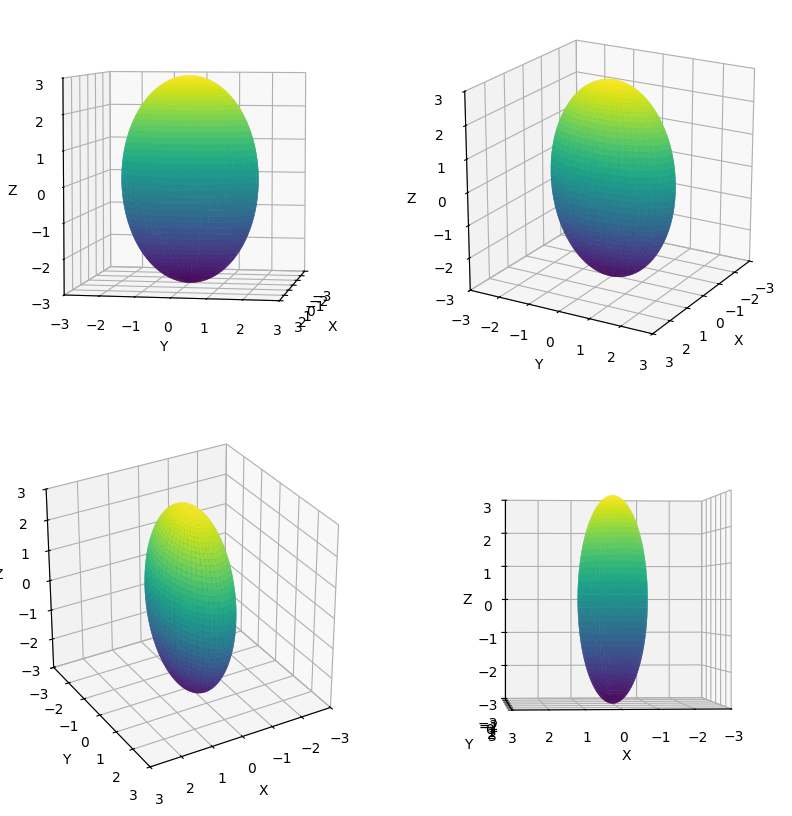

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 导入3D绘图工具包

# ---------------------- 1. 生成参数网格（用于参数化曲面） ----------------------
# 注释掉的原代码：生成笛卡尔坐标系下的线性空间（原可能用于显式曲面）
# x = np.linspace(-2, 2, 100)
# y = np.linspace(-2, 2, 100)

# 生成球面坐标系下的参数范围（用于椭球的参数方程）
# x: 方位角 θ，范围 [0, 2π]（绕Z轴旋转一周）
x = np.linspace(0, 2 * np.pi, 100)
# y: 极角 φ，范围 [0, π]（从Z轴正方向到负方向）
y = np.linspace(0, np.pi, 100)

# 生成网格矩阵 X, Y（将1D参数转换为2D网格，方便向量化计算）
X, Y = np.meshgrid(x, y)

# ---------------------- 2. 创建画布 ----------------------
fig = plt.figure(figsize=(10, 10))  # 设置画布大小为 10×10 英寸

# ---------------------- 3. 定义绘图函数（封装3D曲面绘制逻辑） ----------------------
def plot(ax, X, Y, elev, azim):
    """
    在3D坐标轴上绘制椭球
    参数:
        ax: 3D坐标轴对象
        X, Y: 参数网格矩阵
        elev: 视角仰角（从下往上看的角度，单位：度）
        azim: 视角方位角（绕Z轴旋转的角度，单位：度）
    """
    # ---------------------- 3.1 椭球的参数方程 ----------------------
    # 椭球标准参数方程（半轴长分别为 1, 2, 3）：
    # x = a*cosθ*sinφ, y = b*sinθ*sinφ, z = c*cosφ
    x1 = 1 * np.cos(X) * np.sin(Y)  # X轴半轴长 a=1
    y1 = 2 * np.sin(X) * np.sin(Y)  # Y轴半轴长 b=2
    z1 = 3 * np.cos(Y)               # Z轴半轴长 c=3
    
    # 注释掉的原代码：上半椭球的显式表达式（仅能绘制z≥0的部分）
    # z1 = np.sqrt(9*(1 - x1**2 - 0.25*y1**2))

    # ---------------------- 3.2 绘制3D曲面 ----------------------
    ax.plot_surface(
        x1, y1, z1,        # 曲面的X, Y, Z坐标
        cmap='viridis',     # 颜色映射（viridis是渐变蓝绿色，美观且色盲友好）
        edgecolor='none'    # 隐藏曲面网格线，让表面更光滑
    )

    # ---------------------- 3.3 设置坐标轴属性 ----------------------
    ax.set_xlabel('X')  # 设置X轴标签
    ax.set_ylabel('Y')  # 设置Y轴标签
    ax.set_zlabel('Z')  # 设置Z轴标签
    
    # 设置坐标轴比例为 1:1:1（关键！避免椭球因窗口比例变形）
    ax.set_box_aspect((1, 1, 1))

    # 设置坐标轴范围（统一为 [-3, 3]，完整展示椭球）
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(-3, 3)

    # ---------------------- 3.4 设置3D视角 ----------------------
    ax.view_init(elev=elev, azim=azim)  # 调整观察角度


# ---------------------- 4. 创建4个子图并绘制不同视角的椭球 ----------------------
# 2×2 布局的第1个子图（仰角5°，方位角10°：略微俯视+轻微旋转）
ax1 = fig.add_subplot(221, projection='3d')
# 2×2 布局的第2个子图（仰角20°，方位角30°：更明显的俯视+旋转）
ax2 = fig.add_subplot(222, projection='3d')
# 2×2 布局的第3个子图（仰角30°，方位角60°：进一步调整视角）
ax3 = fig.add_subplot(223, projection='3d')
# 2×2 布局的第4个子图（仰角0°，方位角85°：平视+接近侧面视角）
ax4 = fig.add_subplot(224, projection='3d')

# 分别调用plot函数，传入不同视角参数
plot(ax1, X, Y, 5, 10)
plot(ax2, X, Y, 20, 30)
plot(ax3, X, Y, 30, 60)
plot(ax4, X, Y, 0, 85)

# ---------------------- 5. 显示图形 ----------------------
plt.show()

用行列式求椭圆体体积
以下是添加了详细注释的代码，并附带**线性代数视角下的体积计算原理**详解：

```python
import numpy as np

# ---------------------- 1. 定义椭球的半轴长 ----------------------
# 设椭球在 X, Y, Z 轴上的半轴长分别为 a=1, b=2, c=3
a, b, c = 1, 2, 3

# ---------------------- 2. 方法一：直接使用椭球体积公式 ----------------------
# 椭球体积标准公式：V = (4/3)πabc
# 类比球体积公式（a=b=c时退化为球）：V = (4/3)πr³
vol1 = (4/3) * np.pi * a * b * c

# ---------------------- 3. 方法二：利用线性变换的行列式（几何意义） ----------------------
# 单位球（半径为1的球）的体积：V_unit = (4/3)π*1*1*1 = (4/3)π
volSphere = (4/3) * np.pi

# 构造从单位球到椭球的线性变换矩阵（对角矩阵，沿坐标轴缩放）
# 变换矩阵 T = [[a, 0, 0],
#                [0, b, 0],
#                [0, 0, c]]
# 它的几何意义是：将单位球沿X轴缩放a倍，Y轴缩放b倍，Z轴缩放c倍
transform_matrix = np.diag([a, b, c])

# 计算变换矩阵的行列式 det(T)
# 行列式的几何意义：线性变换的「体积缩放因子」
# 对于对角矩阵，det(T) = a*b*c（各轴缩放因子的乘积）
det = np.linalg.det(transform_matrix)

# 椭球体积 = 单位球体积 × 体积缩放因子（行列式）
vol2 = volSphere * det

# ---------------------- 4. 输出结果 ----------------------
print(f"体积1（直接公式）: {vol1:.2f}")
print(f"单位球体积: {volSphere:.2f}, 行列式det: {det}, 体积2（线性变换）: {vol2:.2f}")
```

### 核心原理详解：线性变换与体积缩放
这段代码展示了**椭球体积的两种等价计算方式**，背后是线性代数中「线性变换对体积的影响」的深刻几何意义：

#### 1. 椭球与单位球的关系
- **单位球**：半径为1的球，满足方程 $x^2 + y^2 + z^2 = 1$，体积为 $(4/3)\pi$。
- **椭球**：可以看作是单位球经过**沿坐标轴的缩放变换**得到的，满足方程 $\frac{x^2}{a^2} + \frac{y^2}{b^2} + \frac{z^2}{c^2} = 1$。

#### 2. 线性变换的矩阵表示
从单位球到椭球的变换，用矩阵乘法表示为：
$$
\begin{bmatrix} x' \\ y' \\ z' \end{bmatrix} = \begin{bmatrix} a & 0 & 0 \\ 0 & b & 0 \\ 0 & 0 & c \end{bmatrix} \begin{bmatrix} x \\ y \\ z \end{bmatrix}
$$
其中 $(x,y,z)$ 是单位球上的点，$(x',y',z')$ 是椭球上的点。

#### 3. 行列式的几何意义：体积缩放因子
对于任意线性变换矩阵 $T$，**行列式 $\det(T)$ 的绝对值等于「单位立方体经过变换后的体积」**，即：
- 如果 $\det(T) > 1$：体积被放大；
- 如果 $\det(T) < 1$：体积被缩小；
- 如果 $\det(T) = 1$：体积保持不变（称为“保体积变换”）。

对于对角矩阵 $\text{diag}(a,b,c)$，行列式就是对角线元素的乘积 $a \times b \times c$，正好是三个轴缩放因子的乘积。

#### 4. 两种方法的等价性
- 方法一直接套用椭球公式：$V = (4/3)\pi abc$；
- 方法二从线性变换出发：$V = \text{单位球体积} \times \det(T) = (4/3)\pi \times (abc)$。

两者数学上完全等价，方法二更深刻地揭示了「椭球是单位球的线性变换」这一几何本质。

运行代码后，你会看到两种方法计算出的体积完全一致（约 25.13），验证了原理的正确性。

In [141]:
a, b, c = 1, 2, 3

vol1 = (4/3) * np.pi * a * b * c

volSphere = (4/3) * np.pi
det = np.linalg.det(np.diag([a, b, c]))
vol2 = volSphere * det

print(f"体积1: {vol1:.2f}")

print(f"单位球体积: {volSphere:.2f}, det: {det}, 体积2: {vol2:.2f}")

体积1: 25.13
单位球体积: 4.19, det: 6.0, 体积2: 25.13


行列式解线性方程组

In [142]:
A = [[ 2, -3, 18],
	 [ 3,  1,  5],
	 [-3,  9,  7]]

B = [7, 9, 6]

D = np.linalg.det(A)

Dx = np.linalg.det([
	[7, -3, 18 ],
	[9,  1,  5 ],
	[6,  9,  7 ]])

Dy = np.linalg.det([
	[ 2,  7, 18],
	[ 3,  9,  5],
	[-3,  6,  7]])

Dz = np.linalg.det([
	[ 2, -3,  7],
	[ 3,  1,  9],
	[-3,  9,  6]])

x = Dx/D
y = Dy/D
z = Dz/D

print(x, y, z)

np.allclose(np.array(A).dot([x, y, z]), B)


2.068181818181817 1.0909090909090904 0.3409090909090913


True

稀疏矩阵

In [143]:
# 从 numpy 库导入 array 函数，用于创建普通数组
from numpy import array
# 从 scipy 稀疏矩阵模块 导入 CSR 稀疏矩阵格式
# CSR：Compressed Sparse Row，按行压缩的稀疏矩阵，专门用来存大量0的矩阵
from scipy.sparse import csr_matrix

# ---------------------- 1. 创建普通稠密矩阵 ----------------------
# 创建一个 3行6列 的普通二维数组（稠密矩阵）
# 特点：所有元素（包括0）都占用内存，0多的时候非常浪费空间
A = array([
[1, 0, 0, 1, 0, 0],
[0, 0, 2, 0, 0, 1],
[0, 0, 0, 2, 0, 0]])
# 打印原始稠密矩阵
print("原始稠密矩阵 A：")
print(A)
print("-"*50)

# ---------------------- 2. 转为 CSR 稀疏矩阵 ----------------------
# 将普通稠密矩阵 A 转换成 CSR 稀疏矩阵 S
# 稀疏矩阵只存储【非0元素】和它们的位置，大大节省内存
S = csr_matrix(A)
# 打印稀疏矩阵
# 输出格式：(行号, 列号) 数值  → 只显示非0元素
print("CSR稀疏矩阵 S（只显示非0元素）：")
print(S)
print("-"*50)

# ---------------------- 3. 稀疏矩阵转回普通稠密矩阵 ----------------------
# .todense()：把稀疏矩阵 S 还原成完整的稠密矩阵（所有0都会显示出来）
# 还原后和原始矩阵 A 完全一样
B = S.todense()
print("稀疏矩阵还原回稠密矩阵 B：")
print(B)

原始稠密矩阵 A：
[[1 0 0 1 0 0]
 [0 0 2 0 0 1]
 [0 0 0 2 0 0]]
--------------------------------------------------
CSR稀疏矩阵 S（只显示非0元素）：
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5 stored elements and shape (3, 6)>
  Coords	Values
  (0, 0)	1
  (0, 3)	1
  (1, 2)	2
  (1, 5)	1
  (2, 3)	2
--------------------------------------------------
稀疏矩阵还原回稠密矩阵 B：
[[1 0 0 1 0 0]
 [0 0 2 0 0 1]
 [0 0 0 2 0 0]]


计算数组的稀疏度

In [144]:
from numpy import array
from numpy import count_nonzero

A = array([
[1, 0, 0, 1, 0, 0],
[0, 0, 2, 0, 0, 1],
[0, 0, 0, 2, 0, 0]])
print(A)

sparsity = 1.0 - count_nonzero(A) / A.size
print(sparsity)

[[1 0 0 1 0 0]
 [0 0 2 0 0 1]
 [0 0 0 2 0 0]]
0.7222222222222222


张量积

In [145]:
A = np.array([1,2,3])
B = np.array([4,5])
C = np.tensordot(A, B, axes=0)
print("C:", C)


# A = np.array([
#     [ 4, 5],
#     [ 8, 10],
#     [12, 15]])

A = np.array([[1,2,3], [4,5,6]])

B = np.array([
    [1,2],
    [3,4]])

C = np.tensordot(A, B, axes=0)
print("T C:", C)


C: [[ 4  5]
 [ 8 10]
 [12 15]]
T C: [[[[ 1  2]
   [ 3  4]]

  [[ 2  4]
   [ 6  8]]

  [[ 3  6]
   [ 9 12]]]


 [[[ 4  8]
   [12 16]]

  [[ 5 10]
   [15 20]]

  [[ 6 12]
   [18 24]]]]
